In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

## Mean Pheno

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
plof_config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(plof_config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
plof_anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = plof_anno_config_df.select(pl.col("annotation")).to_series().to_list()


# genome-wide scores annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
gnomw_anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

gnomw_anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        # .union(set(plof_cols))
    )
    .collect(engine='streaming')
)

anno

encode_ca,ted_domain,mane_exonic,mobi_lip_full,consequence_start_lost,consequence_stop_gained,consequence_splice_acceptor_variant,non_mane_cds,low_complexity_domain,id,loftee_lc,five_prime_utr_variant_consequence_uaug_lost,consequence_missense_variant,not_in_encode,five_prime_utr_variant_consequence_uframeshift,encode_pls,loftee_hc,consequence_splice_donor_variant,region,five_prime_utr_variant_consequence_ustop_gained,encode_tf,non_mane_exonic,encode_dels,encode_ca_tf,encode_ca_ctcf,encode_ca_h3k4me3,consequence_frameshift_variant,gene_name,five_prime_utr_variant_consequence_ustop_lost,consequence_stop_lost,mobi_curated_disorder_priority,encode_pels,mane_cds,five_prime_utr_variant_consequence_uaug_gained
bool,bool,bool,bool,i32,i32,i32,bool,bool,str,i8,u8,i32,bool,u8,bool,i8,i32,str,u8,bool,bool,bool,bool,bool,bool,i32,str,u8,i32,bool,bool,bool,u8
false,false,true,true,0,0,0,false,false,"""chr15:64859998:G:C""",0,0,1,false,0,false,0,0,"""ENSG00000241839""",0,false,false,true,false,false,false,0,"""PLEKHO2""",0,0,false,false,true,0
false,false,true,true,0,0,0,false,true,"""chr1:202729885:A:T""",0,0,1,true,0,false,0,0,"""ENSG00000117139""",0,false,false,false,false,false,false,0,"""KDM5B""",0,0,true,false,true,0
false,true,true,false,0,0,0,false,false,"""chr11:125672628:A:G""",0,0,1,true,0,false,0,0,"""ENSG00000134940""",0,false,false,false,false,false,false,0,"""ACRV1""",0,0,false,false,true,0
false,false,true,false,0,0,0,false,false,"""chr1:202742800:C:T""",0,0,1,false,0,false,0,0,"""ENSG00000117139""",0,false,false,true,false,false,false,0,"""KDM5B""",0,0,false,false,true,0
false,false,true,false,0,0,0,false,false,"""chr1:202735550:A:G""",0,0,1,true,0,false,0,0,"""ENSG00000117139""",0,false,false,false,false,false,false,0,"""KDM5B""",0,0,true,false,true,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,true,true,false,0,0,0,false,false,"""chr2:43825007:T:C""",0,0,0,true,0,false,0,0,"""ENSG00000138075""",0,false,false,false,false,false,false,0,"""ABCG5""",0,0,false,false,true,0
false,true,true,false,0,0,0,false,false,"""chr10:99819216:C:A""",0,0,1,true,0,false,0,0,"""ENSG00000023839""",0,false,false,false,false,false,false,0,"""ABCC2""",0,0,false,false,true,0
true,false,true,false,0,0,0,false,false,"""chr10:99800490:A:T""",0,0,1,false,0,false,0,0,"""ENSG00000023839""",0,false,false,false,false,false,false,0,"""ABCC2""",0,0,false,false,true,0


In [4]:
selected_annos = ['consequence_stop_lost', 'consequence_start_lost', 'consequence_splice_donor_variant', 'loftee_hc', 'consequence_splice_acceptor_variant', 'loftee_lc', 'consequence_stop_gained']

melted_plofs = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="plof_score"
    )
    .with_columns(
        pl.col("plof_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        plof_anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        plof_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('plof_score')-1).abs())
            .otherwise(pl.col('plof_score'))
        )
    )
    
    .filter(
        (pl.col('plof_score') != 0)
    )
    .drop(['annotation_dir'])
    .rename({'annotation': 'plof_type'})
)

melted_plofs

id,region,plof_type,plof_score,category,plof_score_dircor
str,str,str,f32,str,f32
"""chr20:3804961:A:G""","""ENSG00000101224""","""consequence_stop_lost""",1.0,"""plof_consequences""",1.0
"""chr16:2037982:T:C""","""ENSG00000065054""","""consequence_stop_lost""",1.0,"""plof_consequences""",1.0
"""chr14:32154946:T:G""","""ENSG00000100852""","""consequence_stop_lost""",1.0,"""plof_consequences""",1.0
"""chr3:52524355:G:T""","""ENSG00000010327""","""consequence_stop_lost""",1.0,"""plof_consequences""",1.0
"""chr3:52524354:T:C""","""ENSG00000010327""","""consequence_stop_lost""",1.0,"""plof_consequences""",1.0
…,…,…,…,…,…
"""chr10:99804194:C:G""","""ENSG00000023839""","""consequence_stop_gained""",1.0,"""plof_consequences""",1.0
"""chr10:99813079:A:T""","""ENSG00000023839""","""consequence_stop_gained""",1.0,"""plof_consequences""",1.0
"""chr10:96223918:C:A""","""ENSG00000095585""","""consequence_stop_gained""",1.0,"""plof_consequences""",1.0


In [5]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [6]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


plof_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_plofs.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    
    # C. Group by variant/gene to get average phenotype effect per variant
    # .group_by(['id', 'region', 'gene_name'])
    # .agg(
    #     n_phenos = pl.col('phenotype').n_unique(),
    #     median_pheno = pl.col('mean_pheno_value_dircor').median(),
    #     mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
    #     std_pheno = pl.col('mean_pheno_value_dircor').std(),
    # )

    # C. Group by annotation and aggregate
    # .group_by(['annotation'])
    # .agg(
    #     n_vars = pl.col('id').n_unique(),
    #     median_pheno = pl.col('mean_pheno_value_dircor').median(),
    #     mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
    #     std_pheno = pl.col('mean_pheno_value_dircor').std(),
    # )
    # .with_columns(
    #     se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    # )
    # .with_columns(
    #     ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
    #     ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    # )
    .collect(engine='streaming')
)

plof_pheno_df

id,phenotype,mean_pheno_value,n_individuals,region,plof_type,plof_score,category,plof_score_dircor,gene_name,loftee_corr,n_variants,beta,rvat_pval,corr_dir,mean_pheno_value_dircor
str,str,f32,u32,str,str,f32,str,f32,str,f64,u64,f64,f64,f64,f64
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""consequence_stop_gained""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472
"""chr2:21006904:C:A""","""alanine_aminotransferase_int""",-1.148227,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-1.148227
"""chr2:21006904:C:A""","""alanine_aminotransferase_int""",-1.148227,1,"""ENSG00000084674""","""consequence_stop_gained""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-1.148227
"""chr2:21007365:G:T""","""alanine_aminotransferase_int""",-0.270222,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.270222
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20:37254330:C:T""","""whole_body_water_mass_int""",-0.459923,7,"""ENSG00000118702""","""consequence_splice_acceptor_va…",1.0,"""plof_consequences""",1.0,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,0.459923
"""chr20:37256909:C:T""","""whole_body_water_mass_int""",0.083984,3,"""ENSG00000118702""","""consequence_splice_acceptor_va…",1.0,"""plof_consequences""",1.0,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.083984
"""chr20:37256909:C:T""","""whole_body_water_mass_int""",0.083984,3,"""ENSG00000118702""","""loftee_lc""",1.0,"""plof_consequences""",1.0,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.083984


In [7]:
gnomw_anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

selected_annos = ['gpn_star_llr_calibrated_mean', 'cadd_raw', 'gpn_score', 'verphylop'] # 'abexp_abs_max']

gnomw_anno = (
    gnomw_anno
    .join(
        plof_pheno_df[['id', 'region']].unique().lazy(),
        on=['id', 'region']
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(selected_annos))
    )
    .collect(engine='streaming')

    .unpivot(
        index=set(['id', 'region', 'gene_name']),
        on=selected_annos,
        variable_name='annotation',
        value_name='annotation_score',
    )

    .join(
        gnomw_anno_config_df[['annotation', 'annotation_dir']].unique(), 
        on='annotation'
    )
    .with_columns(
        annotation_score_dircor = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

gnomw_anno

id,region,gene_name,annotation,annotation_score,annotation_dir,annotation_score_dircor
str,str,str,str,f32,i8,f32
"""chr5:180316823:G:A""","""ENSG00000131459""","""GFPT2""","""gpn_star_llr_calibrated_mean""",-9.928648,-1,9.928648
"""chr20:47291795:C:A""","""ENSG00000101040""","""ZMYND8""","""gpn_star_llr_calibrated_mean""",-11.921052,-1,11.921052
"""chr18:9195683:C:T""","""ENSG00000101745""","""ANKRD12""","""gpn_star_llr_calibrated_mean""",-10.023309,-1,10.023309
"""chr5:180316863:T:C""","""ENSG00000131459""","""GFPT2""","""gpn_star_llr_calibrated_mean""",-9.869942,-1,9.869942
"""chr1:247444793:C:T""","""ENSG00000162711""","""NLRP3""","""gpn_star_llr_calibrated_mean""",-7.421788,-1,7.421788
…,…,…,…,…,…,…
"""chr2:112756339:A:T""","""ENSG00000169607""","""CKAP2L""","""verphylop""",0.012,1,0.012
"""chr7:117594977:G:A""","""ENSG00000001626""","""CFTR""","""verphylop""",10.211,1,10.211
"""chr16:84854728:G:A""","""ENSG00000103196""","""CRISPLD2""","""verphylop""",11.009,1,11.009


In [8]:
all_vars_df = (
    plof_pheno_df
    .join(
        gnomw_anno.unique(), 
        on=['id', 'region', 'gene_name']
    )
)

all_vars_df

id,phenotype,mean_pheno_value,n_individuals,region,plof_type,plof_score,category,plof_score_dircor,gene_name,loftee_corr,n_variants,beta,rvat_pval,corr_dir,mean_pheno_value_dircor,annotation,annotation_score,annotation_dir,annotation_score_dircor
str,str,f32,u32,str,str,f32,str,f32,str,f64,u64,f64,f64,f64,f64,str,f32,i8,f32
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472,"""cadd_raw""",6.57924,1,6.57924
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472,"""verphylop""",2.051,1,2.051
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472,"""gpn_score""",-6.8,-1,6.8
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""loftee_hc""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472,"""gpn_star_llr_calibrated_mean""",-6.833787,-1,6.833787
"""chr2:21010535:G:C""","""alanine_aminotransferase_int""",-0.227472,1,"""ENSG00000084674""","""consequence_stop_gained""",1.0,"""plof_consequences""",1.0,"""APOB""",0.028104,11795,0.190438,9.6228e-11,1.0,-0.227472,"""cadd_raw""",6.57924,1,6.57924
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr20:37251215:A:G""","""whole_body_water_mass_int""",0.049474,3,"""ENSG00000118702""","""consequence_stop_lost""",1.0,"""plof_consequences""",1.0,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.049474,"""gpn_star_llr_calibrated_mean""",-4.491067,-1,4.491067
"""chr20:37256888:A:T""","""whole_body_water_mass_int""",0.655092,1,"""ENSG00000118702""","""consequence_start_lost""",1.0,"""plof_consequences""",1.0,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.655092,"""gpn_star_llr_calibrated_mean""",-8.766029,-1,8.766029
"""chr20:37256888:A:T""","""whole_body_water_mass_int""",0.655092,1,"""ENSG00000118702""","""consequence_start_lost""",1.0,"""plof_consequences""",1.0,"""GHRH""",-0.023754,4585,-0.322347,2.8641e-8,-1.0,-0.655092,"""verphylop""",4.014,1,4.014


In [9]:
per_plof_corr = (
    all_vars_df
    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation", "plof_type"])
        .alias(f"{c}_rank")
        for c in ['annotation_score_dircor', 'mean_pheno_value_dircor']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation", "plof_type"])
    .agg(
        n_variants = pl.col("id").count(),
        rank_correlation = pl.corr("annotation_score_dircor_rank", "mean_pheno_value_dircor_rank", propagate_nans=True),
        mean_score_dircor = pl.col("annotation_score_dircor").mean(),
        std_score_dircor = pl.col("annotation_score_dircor").std(),
    )

    .join(
        gnomw_anno_config_df.select(['annotation', 'label', 'color']).unique(),
        on='annotation'
    )
    .join(
        plof_anno_config_df.rename({
            'annotation':'plof_type', 
            'label':'label_plof',
        }).select(['plof_type', 'label_plof']).unique(),
        on='plof_type'
    )

    # Filter out low N gene-phenotype pairs
    .filter(pl.col('n_variants') >= 10)
    .drop_nans()
)

count_df = (
    per_plof_corr
    .group_by(['label_plof', 'annotation'])
    .agg(
        n_gene_pheno = pl.len()
    )
    .with_columns(
        n_label_plof = pl.col('label_plof') + '\n(n=' + pl.col('n_gene_pheno').cast(pl.Utf8) + ')'
    )
)

per_plof_corr = per_plof_corr.join(count_df, on=['label_plof', 'annotation'])
per_plof_corr

region,gene_name,phenotype,annotation,plof_type,n_variants,rank_correlation,mean_score_dircor,std_score_dircor,label,color,label_plof,n_gene_pheno,n_label_plof
str,str,str,str,str,u64,f64,f32,f32,str,str,str,u64,str
"""ENSG00000138688""","""KIAA1109""","""arm_fat_percentage_left_int""","""gpn_star_llr_calibrated_mean""","""consequence_splice_donor_varia…",35,-0.026611,10.925614,1.900817,"""GPN-Star""","""#942c80""","""VEP Splice Donor""",273,"""VEP Splice Donor (n=273)"""
"""ENSG00000167676""","""PLIN4""","""trunk_fat_percentage_int""","""gpn_score""","""loftee_hc""",17,0.112745,5.281765,2.439353,"""GPN-MSA""","""pink""","""LOFTEE HC""",923,"""LOFTEE HC (n=923)"""
"""ENSG00000130164""","""LDLR""","""apolipoprotein_b_int""","""verphylop""","""consequence_stop_gained""",14,0.167217,3.776,4.979269,"""Vertebrate PhyloP""","""#483D8B""","""VEP Stop Gained""",765,"""VEP Stop Gained (n=765)"""
"""ENSG00000159899""","""NPR2""","""whole_body_fatfree_mass_int""","""gpn_star_llr_calibrated_mean""","""consequence_stop_gained""",15,0.128571,10.349586,1.179972,"""GPN-Star""","""#942c80""","""VEP Stop Gained""",765,"""VEP Stop Gained (n=765)"""
"""ENSG00000168769""","""TET2""","""high_light_scatter_reticulocyt…","""verphylop""","""consequence_stop_gained""",229,-0.095661,3.932454,2.955181,"""Vertebrate PhyloP""","""#483D8B""","""VEP Stop Gained""",765,"""VEP Stop Gained (n=765)"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000164151""","""ICE1""","""trunk_fatfree_mass_int""","""gpn_star_llr_calibrated_mean""","""consequence_stop_gained""",21,0.209091,4.463233,4.530414,"""GPN-Star""","""#942c80""","""VEP Stop Gained""",765,"""VEP Stop Gained (n=765)"""
"""ENSG00000171914""","""TLN2""","""high_light_scatter_reticulocyt…","""gpn_score""","""consequence_stop_gained""",41,0.008014,11.052438,1.573243,"""GPN-MSA""","""pink""","""VEP Stop Gained""",765,"""VEP Stop Gained (n=765)"""
"""ENSG00000217128""","""FNIP1""","""shbg_int""","""gpn_score""","""consequence_stop_gained""",15,-0.125,9.286,1.464069,"""GPN-MSA""","""pink""","""VEP Stop Gained""",765,"""VEP Stop Gained (n=765)"""


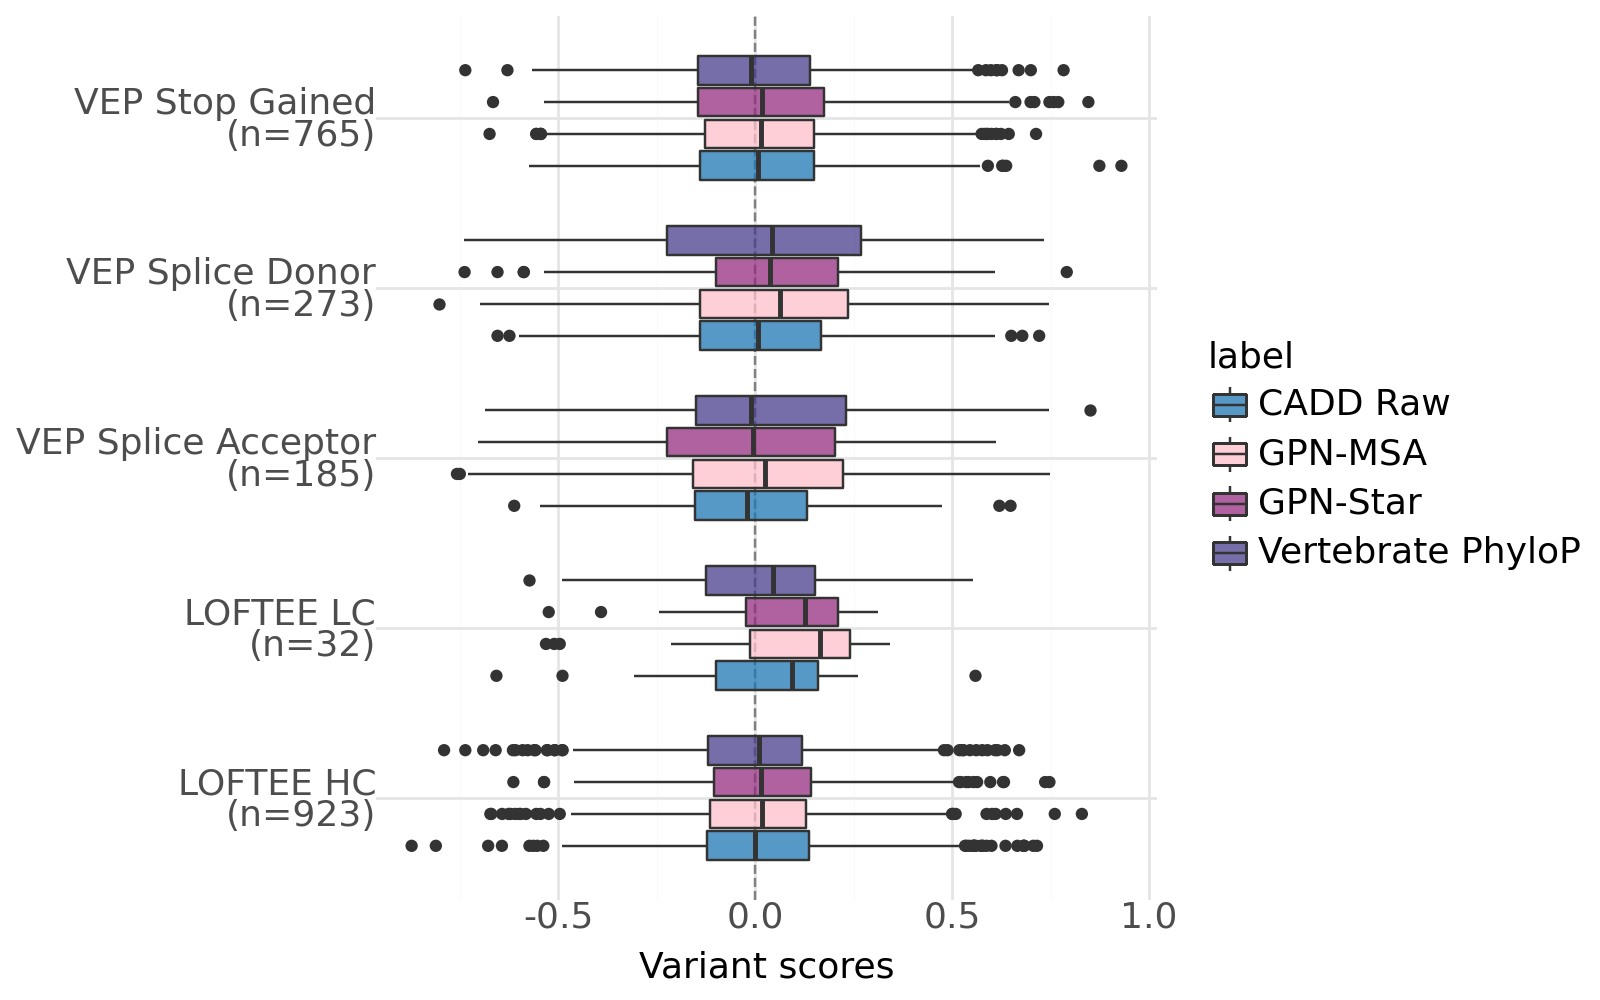

In [10]:

color_dict = dict(zip(gnomw_anno_config_df['label'], gnomw_anno_config_df['color']))

(
    ggplot(
        per_plof_corr,
        aes(y='rank_correlation', x='n_label_plof', fill='label')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_boxplot(width=0.75, alpha=0.75)
    + scale_fill_manual(values=color_dict)
    + labs(
        x='',
        y='Variant scores'
    )
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(8, 5),
        # legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        strip_text=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
plot_df = (
    per_plof_corr
    .group_by(['annotation', 'plof_type'])
    .agg(
        avg_corr = pl.col('rank_correlation').mean(),
        std_corr = pl.col('rank_correlation').std(),
        n_pairs = pl.col('rank_correlation').count(),
    )
    .with_columns(
        se_corr = pl.col('std_corr') / pl.col('n_pairs').sqrt()
    )
    .with_columns(
        ci_low_corr = pl.col('avg_corr') - 1.96*pl.col('se_corr'),
        ci_high_corr = pl.col('avg_corr') + 1.96*pl.col('se_corr'),
    )
)

plot_df

annotation,plof_type,avg_corr,std_corr,n_pairs,se_corr,ci_low_corr,ci_high_corr
str,str,f64,f64,u64,f64,f64,f64
"""gpn_score""","""consequence_splice_acceptor_va…",0.015936,0.273638,185,0.020118,-0.023495,0.055368
"""cadd_raw""","""consequence_splice_acceptor_va…",-0.017808,0.225932,185,0.016611,-0.050366,0.014749
"""gpn_score""","""consequence_stop_gained""",0.014145,0.226543,765,0.008191,-0.001909,0.030198
"""gpn_star_llr_calibrated_mean""","""consequence_splice_acceptor_va…",-0.013276,0.294924,185,0.021683,-0.055775,0.029223
"""cadd_raw""","""consequence_splice_donor_varia…",0.007637,0.256075,273,0.015498,-0.02274,0.038014
…,…,…,…,…,…,…,…
"""verphylop""","""consequence_stop_gained""",-0.006186,0.226604,765,0.008193,-0.022244,0.009872
"""gpn_star_llr_calibrated_mean""","""loftee_hc""",0.030131,0.196327,923,0.006462,0.017465,0.042797
"""gpn_star_llr_calibrated_mean""","""consequence_splice_donor_varia…",0.043877,0.244716,273,0.014811,0.014847,0.072906


In [12]:
from scipy.stats import spearmanr


# 1. PREPARE DATA
# plot_data = avg_plof_plot
plot_data = avg_plof_plot.filter(
    pl.col('plof_type') == 'loftee_hc'
)

# 2. DEFINE CUSTOM FUNCTION
def get_spearman_stats(df):
    res = spearmanr(df['annotation_score_dircorr'], df['mean_pheno'])
    
    # Use Python's f-string here (it supports .2e, .2f, etc.)
    txt = f"ρ = {res.statistic:.2f}\np = {res.pvalue:.2e}"
    
    return pl.DataFrame({
        "label": df['label'][0],
        "label_text": [txt],  # <--- Return the pre-formatted string
        "x_pos": [df['annotation_score_dircorr'].min()],
        "y_pos": [df['mean_pheno'].max()]
    })

# 3. APPLY TO GROUPS
cor_df = (
    plot_data
    .group_by("label", maintain_order=True)
    .map_groups(get_spearman_stats)
)

# 4. PLOT
(
    ggplot(plot_data, aes(x='annotation_score_dircorr', y='mean_pheno'))
    # + geom_bin_2d(bins=50, aes(fill='..count..'))
    + geom_point(color='black', alpha=0.21, size=0.75)
    + geom_smooth(method='lm', se=True)
    + labs(
        x='Annotation score (direction corrected)',
        y='Mean phenotype effect\n(direction corrected)'
    )
    # Add the text with the p-value
    + geom_text(
        data=cor_df,
        mapping=aes(x='x_pos', y='y_pos', label='label_text'),
        ha='left',
        va='top',
        size=10,
        inherit_aes=False
    )
    + facet_wrap('~label', scales='free', ncol=3)
    # + facet_grid('label_plof~label', scales='free')
    + theme_minimal()
    + theme(
        figure_size=(8, 3.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        strip_text=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

NameError: name 'avg_plof_plot' is not defined